## Validating & Refining the Tiers

In Notebook 1, I proposed initial tier definitions based on percentile thresholds:

| Tier | Pressures Per Game | Career High Sacks |
|------|-------------------|-------------------|
| **Elite** | ≥ 1.4 | ≥ 10 |
| **Hit** | ≥ 0.9 | ≥ 6 |
| **Role** | ≥ 0.6 | < 6 |
| **Bust** | < 0.6 | < 4 |

After applying these to the data and reviewing the players in each tier, I found the "Elite" group was too large and included several players who are good starters but not game-changers (e.g., Chase Young, Leonard Floyd, Kayvon Thibodeaux).

**Revised tiers (after validation):**

| Tier | Pressures Per Game | Career High Sacks | What It Means |
|------|-------------------|-------------------|---------------|
| **Elite** | ≥ 2.0 | ≥ 14 | Top-tier game-changers |
| **Hit** | ≥ 1.2 | ≥ 8 | Quality starters |
| **Role** | ≥ 0.7 | ≥ 4 | Rotational contributors |
| **Bust** | < 0.7 | < 4 | Never became a factor |

These revised thresholds will be used for all remaining analysis.

In [57]:
# CELL to assign tiers to players

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


DL_summary = pd.read_csv('dl_analysis_data.csv')


edge_rushers = DL_summary[DL_summary['position_group'] == 'Edge'].copy()

def assign_edge_tier(row):
    pressures = row['nfl_pressures_per_game']
    sacks = row['nfl_sacks_career_high']
    
    if pressures >= 2.0 and sacks >= 14:
        return 'Elite'
    elif pressures >= 1.2 and sacks >= 8:
        return 'Hit'
    elif pressures >= 0.7 and sacks >= 4:
        return 'Role'
    else:
        return 'Bust'
    
# Applying the tiers
edge_rushers['nfl_tier'] = edge_rushers.apply(assign_edge_tier, axis=1)

# Checking the distribution
print("Tier Distribution:")
print(edge_rushers['nfl_tier'].value_counts())
print(f"\nTotal players: {len(edge_rushers)}")

# Print with tier headers
for tier in ['Elite', 'Hit', 'Role', 'Bust']:
    print(f"\n{'='*60}")
    print(f"TIER: {tier} ({len(edge_rushers[edge_rushers['nfl_tier'] == tier])} players)")
    print('='*60)
    tier_players = edge_rushers[edge_rushers['nfl_tier'] == tier][['Name', 'nfl_pressures_per_game', 'nfl_sacks_career_high']]
    print(tier_players.to_string(index=False))

Tier Distribution:
nfl_tier
Bust     160
Role     114
Hit       61
Elite     13
Name: count, dtype: int64

Total players: 348

TIER: Elite (13 players)
            Name  nfl_pressures_per_game  nfl_sacks_career_high
   Myles Garrett                   2.699                   23.0
       T.J. Watt                   2.854                   22.5
 Shaquil Barrett                   2.386                   19.5
  Chandler Jones                   2.149                   19.0
       Nick Bosa                   2.818                   18.5
Trey Hendrickson                   2.460                   17.5
Josh Hines-Allen                   2.198                   17.5
     Khalil Mack                   2.009                   17.0
 Danielle Hunter                   2.215                   16.5
       J.J. Watt                   2.540                   16.0
Aidan Hutchinson                   3.018                   14.5
      Von Miller                   2.000                   14.5
     Maxx Crosby

## Draft Capital vs. NFL Edge Tiers

With the NFL tier classifications finalized, the natural next question is: **where are these players being drafted?**

If NFL teams make proper investments in the EDGE position, we should expect to see:
- **Elite** players concentrated in the first round
- **Hit** players spread across Rounds 1-3
- **Role** players appearing in the middle rounds
- **Bust** players dominating Day 3

To test this, I grouped Edge rushers by their draft round and calculated the percentage of players in each tier per round. The stacked bar chart below visualizes the relationship between draft capital and NFL success.

draft_round
1.0    50
2.0    43
3.0    45
4.0    23
5.0    20
6.0     7
7.0    12
dtype: int64
Total Players
200
nfl_tier         Elite        Hit       Role       Bust
draft_round                                            
1.0          12.000000  32.000000  36.000000  20.000000
2.0           0.000000  23.255814  41.860465  34.883721
3.0           4.444444  13.333333  35.555556  46.666667
4.0           4.347826  13.043478  34.782609  47.826087
5.0           0.000000   5.000000  35.000000  60.000000
6.0           0.000000   0.000000  14.285714  85.714286
7.0           0.000000   8.333333   8.333333  83.333333


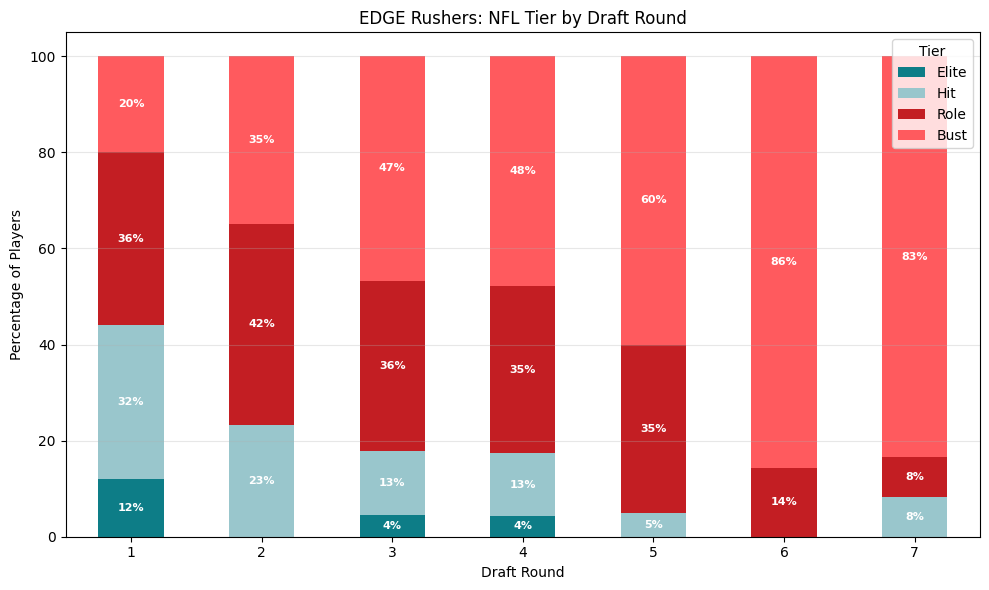

In [58]:
# Draft Capital vs NFL EDGE Tiers
import matplotlib.pyplot as plt
import pandas as pd

# Calculate hit rate by round
round_tier = edge_rushers.groupby(['draft_round', 'nfl_tier']).size().unstack(fill_value=0)
round_tier_pct = round_tier.div(round_tier.sum(axis=1), axis=0) * 100

# Reorder Tiers
tier_order = ['Elite', 'Hit', 'Role', 'Bust']
round_tier_pct = round_tier_pct[tier_order]

players_per_round = round_tier.sum(axis=1)
print(players_per_round)
print('Total Players')
print(sum(players_per_round))


# Print values for raw numbers
print(round_tier_pct)

# Visualization: Bar Chart
fig, ax = plt.subplots(figsize=(10,6))

round_tier_pct.plot(kind='bar', stacked=True, ax=ax, color=['#0d7d87','#99c6cc','#c31e23','#ff5a5e'])
ax.set_xlabel('Draft Round')
ax.set_ylabel('Percentage of Players')
ax.set_title('EDGE Rushers: NFL Tier by Draft Round')
ax.legend(title='Tier')
ax.grid(True, alpha=0.3, axis='y')



ax.set_xticklabels([int(x) for x in round_tier.index], rotation=0)

# Add percentage labels inside the bars
for i, (round_num, row) in enumerate(round_tier_pct.iterrows()):
    # Calculate cumulative sum to position labels correctly
    cumsum = 0
    for tier in tier_order:
        value = row[tier]
        if value > 3:  # Anything smaller than 3 will be hard to read
            # Position label in the middle of the segment
            y_position = cumsum + (value / 2)
            ax.text(i, y_position, f'{value:.0f}%', 
                    ha='center', va='center', 
                    fontsize=8, fontweight='bold', 
                    color='white')  # White for contrast
            cumsum += value

# for i, round_num in enumerate(round_tier.index):
#     total = round_tier.sum(axis=1)[round_num]
#     ax.text(i, 95, f'n={total}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## Analysis: Draft Capital vs. Edge Rusher Success

### The Data

**Sample Sizes by Round**

| Round | Total Players |
|-------|---------------|
| 1st   | 50            |
| 2nd   | 43            |
| 3rd   | 45            |
| 4th   | 23            |
| 5th   | 20            |
| 6th   | 7             |
| 7th   | 12            |

*Note: Rounds 6-7 have small sample sizes. Findings from these rounds should be interpreted with caution.*

**Tier Distribution by Round (%)**

| Round | Elite | Hit | Role | Bust |
|-------|-------|-----|------|------|
| 1st   | 12.0% | 32.0% | 36.0% | 20.0% |
| 2nd   | 0.0%  | 23.3% | 41.9% | 34.9% |
| 3rd   | 4.4%  | 13.3% | 35.6% | 46.7% |
| 4th   | 4.3%  | 13.0% | 34.8% | 47.8% |
| 5th   | 0.0%  | 5.0%  | 35.0% | 60.0% |
| 6th   | 0.0%  | 0.0%  | 14.3% | 85.7% |
| 7th   | 0.0%  | 8.3%  | 8.3%  | 83.3% |

---

### Four Key Takeaways

**1. Elite Edge Rushers Are Found in Round 1 — Everywhere Else Is Luck**

Across 200+ Edge players in this dataset, only three have become Elite outside the first round:

- Round 3: 2 players (4.4%)
- Round 4: 1 player (4.3%)

That's not a scouting edge. That's randomness. If you want an Elite Edge rusher, you need a first-round pick.

**2. Hit Rate Drops at Two Distinct Cliffs: After Round 1 and After Round 4**

| Threshold | Hit Rate (Elite + Hit) |
|-----------|------------------------|
| Round 1   | 44.0%                  |
| Round 2   | 23.3%                  |
| Round 4   | 17.4%                  |
| Round 5+  | ~5%                    |

The first cliff (Round 1 → 2) represents the drop from premium talent to starters. The second cliff (Round 4 → 5) represents the drop from developmental prospects to pure lottery tickets.

*Note: Sample sizes after Round 4 are small (39 total players in Rounds 5-7), but the pattern is consistent enough to treat as a signal.*

**3. Role Player Rates Are Remarkably Stable Through Round 5**

From Round 1 through Round 5, the percentage of players who become Role players hovers between 35-42%:

| Round | Role Player Rate |
|-------|------------------|
| 1st   | 36.0%            |
| 2nd   | 41.9%            |
| 3rd   | 35.6%            |
| 4th   | 34.8%            |
| 5th   | 35.0%            |

This suggests that *every* round through Day 2 produces rotational contributors at roughly the same rate. The difference between a successful and unsuccessful pick in these rounds is whether that player becomes a starter (Hit) or a role player — not whether they become a role player at all.

After Round 5, the role player rate collapses (14.3% in Round 6, 8.3% in Round 7), and the bust rate exceeds 80%.

**4. Edge Rusher Is a Premium Position — and Teams Know It**

Since 2018, teams have drafted 43+ Edge rushers in each of the first three rounds. Compare that to Rounds 4-7, which collectively account for only 62 Edge selections — despite having more total picks available.

This isn't an accident. General managers invest premium capital in the position because they know the drop-off is real. The data backs them up: the best Edge rushers are found early, and teams are willing to pay the price to find them.

---

### The Bottom Line

> **Edge rusher is a position where you get what you pay for.**

Round 1 is the only reliable path to an Elite player.  
Round 2 is the best bet for a solid starter.  
Rounds 3-5 produce role players at a consistent rate.  
Rounds 6-7 are a lottery with terrible odds.

If you need an Edge rusher and you don't have a first-round pick, you're not shopping for a star — you're shopping for a contributor. And even that is harder than it looks.

## College Stats vs. NFL Tiers

Now that we've established that draft capital matters for Edge rushers, the next question is: **can college production tell us anything more?**

Draft position tells us what NFL teams *thought* of a prospect. College stats tell us what that prospect *actually did* on the field. By comparing the two, we can identify which metrics separate future stars from busts — and which ones teams might be overvaluing.

### Merging College Stats

To answer this, I merged college production data (sacks, TFLs, and tackles per game) with the NFL tier classifications from the previous section. The merge was done on player name, pulling career averages from each player's college career.

[Insert query and merge code here]

### Which Stats Matter?

For Edge rushers, I focused on three college metrics:

| Metric | Why It Matters |
|--------|----------------|
| **Sacks per game** | The most obvious measure of pass-rush production. Does it translate? |
| **TFLs per game** | Measures backfield disruption beyond just sacks. Shows a player's ability to create negative plays. |
| **Tackles per game** | A proxy for motor and consistency. High-volume tacklers may be more reliable. |

I also considered conference strength and games played, but these three production metrics are the most direct measures of college performance.

The goal is simple: **which of these metrics best separates Elite Edge rushers from the rest?**

---

## College Stats/Combine Metrics vs. NFL Tiers

Now that we've established that draft capital matters for Edge rushers, the next question is: **can college production tell us anything more?**

Draft position tells us what NFL teams *thought* of a prospect. College stats tell us what that prospect *actually did* on the field. By comparing the two, we can identify which metrics separate future stars from busts — and which ones teams might be overvaluing.

### Merging College Stats

To answer this, I merged college production data (sacks, TFLs, and tackles per game) with the NFL tier classifications from the previous section. The merge was done on player name, pulling career averages from each player's college career.

In [59]:
# CELL to Merge College Stats for EDGE Players

import sqlite3
import pandas as pd


conn = sqlite3.connect('nfl_analytics_dl.db')

college_query= """
    SELECT
        cs.Name,
        cs.Year,

        -- PER GAME STATS
        ROUND(CAST(SUM(cs.TS) AS FLOAT) / NULLIF(SUM(cs.Games), 0), 3) as college_sacks_per_game,
        ROUND(CAST(SUM(ct.TFL) AS FLOAT) / NULLIF(SUM(cs.Games), 0), 3) as college_tfl_per_game,
        
        -- CAREER HIGH STATS
        MAX(cs.TS) AS college_sacks_career_high,
        MAX(ct.TFL) AS college_tfl_career_high,

        -- COMBINE STATS
        c.FortyYd AS forty_time,
        c.Bench AS bench_press,
        c.ThreeCone AS three_cone,
        c.BroadJump AS broad_jump,
        c.Vertical AS vertical_jump,

        -- COLLEGE CONFERENCE
        cs.Conference as college_conference
    FROM college_sacks cs
    LEFT JOIN college_tfls ct ON cs.Name = ct.Name AND cs.Year = ct.Year
    LEFT JOIN college_tackles ctack ON cs.Name = ctack.Name AND cs.Year = ctack.Year
    LEFT JOIN combine c ON c.Player = cs.Name
    GROUP BY cs.Name
"""

college_combine_stats = pd.read_sql_query(college_query, conn)
conn.close()
print(f"College stats loaded: {len(college_combine_stats)} players")

# Merge with NFL Data
edge_with_college_combine = edge_rushers.merge(
    college_combine_stats,
    left_on=['Name'],
    right_on=['Name'],
    how='left'
)



College stats loaded: 1277 players


### Which Stats Matter?

For Edge rushers, I focused on two types of pre-draft data: **college production** and **combine athletic testing**.

#### College Production

| Metric | Why It Matters |
|--------|----------------|
| **Sacks per game** | The most direct measure of pass-rush production. Does it translate to the NFL? |
| **TFLs per game** | Measures backfield disruption beyond just sacks. Shows a player's ability to create negative plays against both the pass and run. |

*Note: Tackles per game was intentionally excluded. For Edge rushers, tackles are heavily scheme-dependent and don't separate pass-rush specialists from all-around players.*

#### Combine Athletic Testing

| Metric | What It Measures | Why It Matters for Edge |
|--------|------------------|-------------------------|
| **40-yard dash** | Straight-line speed | Speed off the edge to beat tackles |
| **Bench press** | Upper body strength | Power to shed blocks and hold the edge |
| **3-cone drill** | Agility and change of direction | Bend around the edge — critical for pass rushers |
| **Broad jump** | Explosive lower-body power | First-step burst and closing speed |

The goal is simple: **Which of these metrics best separates Elite Edge rushers from the rest?**


In [ ]:
# CELL for correlation matrix

import seaborn as sns
import matplotlib.pyplot as plt

metrics = [
    'college_sacks_per_game',
    'college_tfl_per_game',
    'college_sacks_career_high',
    'college_tfl_career_high',
    'forty_time',
    'bench_press',
    'three_cone',
    'broad_jump',
    'vertical_jump',
    'nfl_pressures_per_game', 
    'nfl_sacks_per_game'
]

# Filter to players with all metrics (drop NaN)
corr_data = edge_with_college_combine[metrics]


# Calculate correlation matrix
corr_matrix = corr_data.corr()

# Print correlation with NFL pressures
print("CORRELATION WITH NFL PRESSURES PER GAME")
print("="*50)
print(corr_matrix['nfl_pressures_per_game'].sort_values(ascending=False).round(3))


CORRELATION WITH NFL PRESSURES PER GAME
nfl_pressures_per_game       1.000
nfl_sacks_per_game           0.880
college_sacks_per_game       0.285
college_sacks_career_high    0.285
college_tfl_per_game         0.266
college_tfl_career_high      0.256
bench_press                  0.198
broad_jump                   0.155
vertical_jump                0.154
forty_time                  -0.216
three_cone                  -0.307
Name: nfl_pressures_per_game, dtype: float64


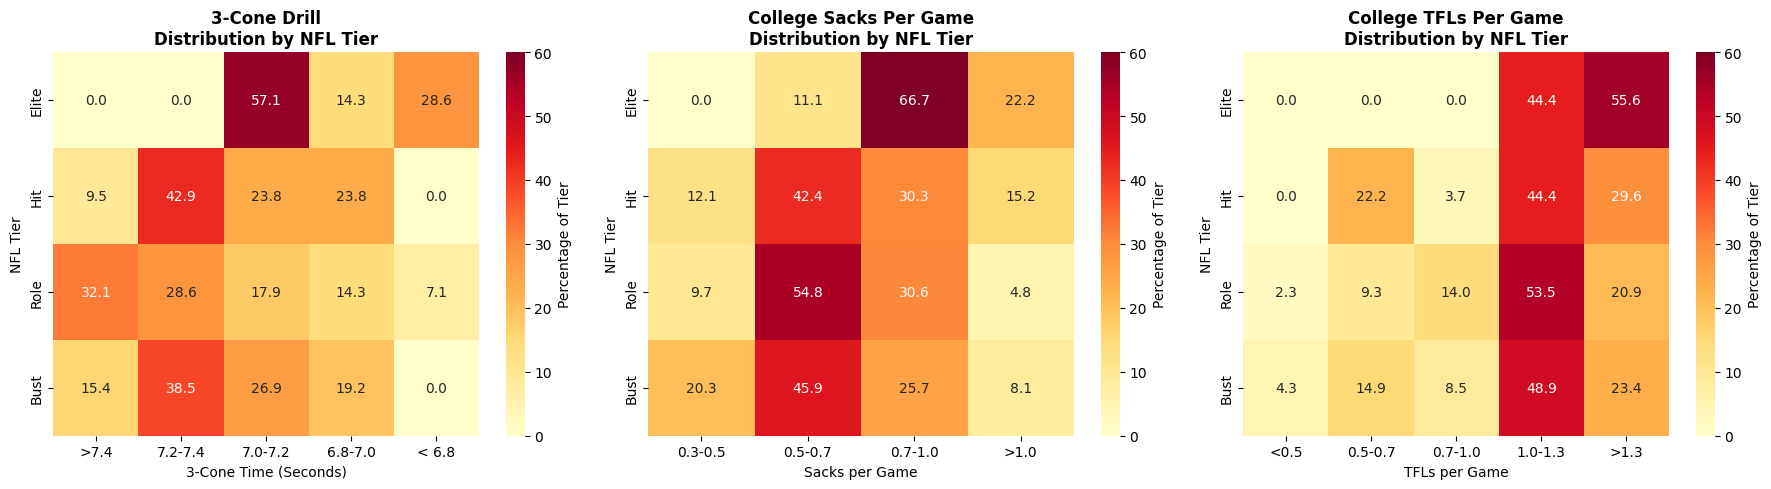


RAW COUNTS (for context)

3-Cone Drill:
metric_bin  < 6.8  6.8-7.0  7.0-7.2  7.2-7.4  >7.4
nfl_tier                                          
Bust            0        5        7       10     4
Elite           2        1        4        0     0
Hit             0        5        5        9     2
Role            2        4        5        8     9

College Sacks Per Game:
metric_bin  0.3-0.5  0.5-0.7  0.7-1.0  >1.0
nfl_tier                                   
Bust             15       34       19     6
Elite             0        1        6     2
Hit               4       14       10     5
Role              6       34       19     3

College TFLs Per Game:
metric_bin  <0.5  0.5-0.7  0.7-1.0  1.0-1.3  >1.3
nfl_tier                                         
Bust           2        7        4       23    11
Elite          0        0        0        4     5
Hit            0        6        1       12     8
Role           1        4        6       23     9


In [ ]:
# Heatmap of average metrics by tier
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Defining our bins for each metric
bin_definitions = {
    'three_cone': {
        'bins': [0, 6.8, 7.0, 7.2, 7.4, 10],
        'labels': ['< 6.8', '6.8-7.0', '7.0-7.2', '7.2-7.4', '>7.4'],
        'title': '3-Cone Drill',
        'xlabel': '3-Cone Time (Seconds)',
        'display_order': ['>7.4', '7.2-7.4', '7.0-7.2', '6.8-7.0', '< 6.8']  # Worst to Best
    },
    'college_sacks_per_game': {
        'bins': [0, 0.3, 0.5, 0.7, 1.0, 10],
        'labels': ['<0.3', '0.3-0.5', '0.5-0.7', '0.7-1.0', '>1.0'],
        'title': 'College Sacks Per Game',
        'xlabel': 'Sacks per Game',
        'display_order': ['<0.3', '0.3-0.5', '0.5-0.7', '0.7-1.0', '>1.0']  # Worst to Best
    },
    'college_tfl_per_game': {
        'bins': [0, 0.5, 0.7, 1.0, 1.3, 10],
        'labels': ['<0.5', '0.5-0.7', '0.7-1.0', '1.0-1.3', '>1.3'],
        'title': 'College TFLs Per Game',
        'xlabel': 'TFLs per Game',
        'display_order': ['<0.5', '0.5-0.7', '0.7-1.0', '1.0-1.3', '>1.3']  # Worst to Best
    }
}

# Figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (metric, config) in enumerate(bin_definitions.items()):
    # Create a copy of the data
    temp_data = edge_with_college_combine[['nfl_tier', metric]].copy()
    
    # Bin the metric
    temp_data['metric_bin'] = pd.cut(
        temp_data[metric],
        bins=config['bins'],
        labels=config['labels'],
        right=False
    )
    
    # Create a crosstab: tiers vs metric bins
    cross_tab = pd.crosstab(
        temp_data['nfl_tier'],
        temp_data['metric_bin'],
        normalize='index'
    ) * 100
    
    # Reorder tiers for consistency
    tier_order = ['Elite', 'Hit', 'Role', 'Bust']
    cross_tab = cross_tab.reindex(tier_order)
    
    # Reorder columns: Worst to Best (left to right)
    # Only keep columns that actually exist in the crosstab
    existing_cols = [col for col in config['display_order'] if col in cross_tab.columns]
    cross_tab = cross_tab[existing_cols]
    
    # Plot heatmap
    sns.heatmap(
        cross_tab,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Percentage of Tier'},
        ax=axes[i],
        vmin=0,
        vmax=60
    )
    axes[i].set_title(f'{config["title"]}\nDistribution by NFL Tier', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(config['xlabel'])
    axes[i].set_ylabel('NFL Tier')

plt.tight_layout()
plt.show()

# Also print raw counts for reference
print("\nRAW COUNTS (for context)")
print("="*60)

for metric in bin_definitions.keys():
    temp_data = edge_with_college_combine[['nfl_tier', metric]].dropna().copy()
    temp_data['metric_bin'] = pd.cut(
        temp_data[metric],
        bins=bin_definitions[metric]['bins'],
        labels=bin_definitions[metric]['labels'],
        right=False
    )
    print(f"\n{bin_definitions[metric]['title']}:")
    print(pd.crosstab(temp_data['nfl_tier'], temp_data['metric_bin']))


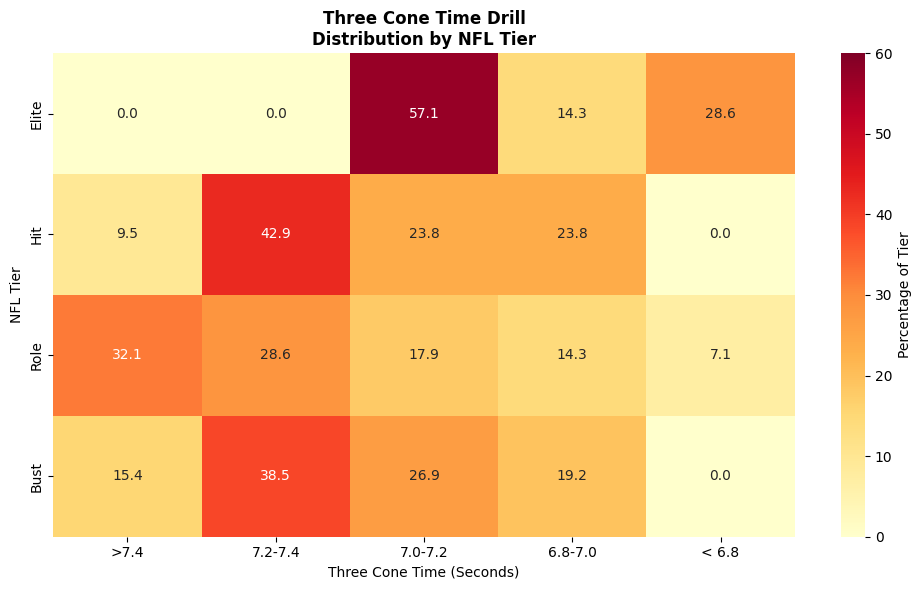

In [92]:
# Heatmap of average metrics by tier
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

three_cone_data = edge_with_college_combine[['nfl_tier', 'three_cone']]

plt.figure(figsize=(10, 6))


three_cone_data['bin'] = pd.cut(
    three_cone_data['three_cone'],
    bins=bin_definitions['three_cone']['bins'],
    labels=bin_definitions['three_cone']['labels'],
    right=False
)
c_tab = pd.crosstab(
    index=three_cone_data['nfl_tier'],
    columns=three_cone_data['bin'], 
    normalize='index'
) *100

 # Reorder tiers for consistency
tier_order = ['Elite', 'Hit', 'Role', 'Bust']
c_tab = c_tab.reindex(tier_order)

# Only keep columns that actually exist in the crosstab
existing_cols = [col for col in bin_definitions['three_cone']['display_order'] if col in c_tab.columns]
c_tab = c_tab[existing_cols]
    
# Plot heatmap
sns.heatmap(
    c_tab,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Percentage of Tier'},
    vmin=0,
    vmax=60
)
plt.title(f'Three Cone Time Drill\nDistribution by NFL Tier', fontsize=12, fontweight='bold')
plt.xlabel('Three Cone Time (Seconds)')
plt.ylabel('NFL Tier')

plt.tight_layout()
plt.show()

### Comparing Sacks Per Game for Edge Rushers to Draft Position

C:\Users\Owner\AppData\Local\Temp\ipykernel_3068\257974386.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=10)


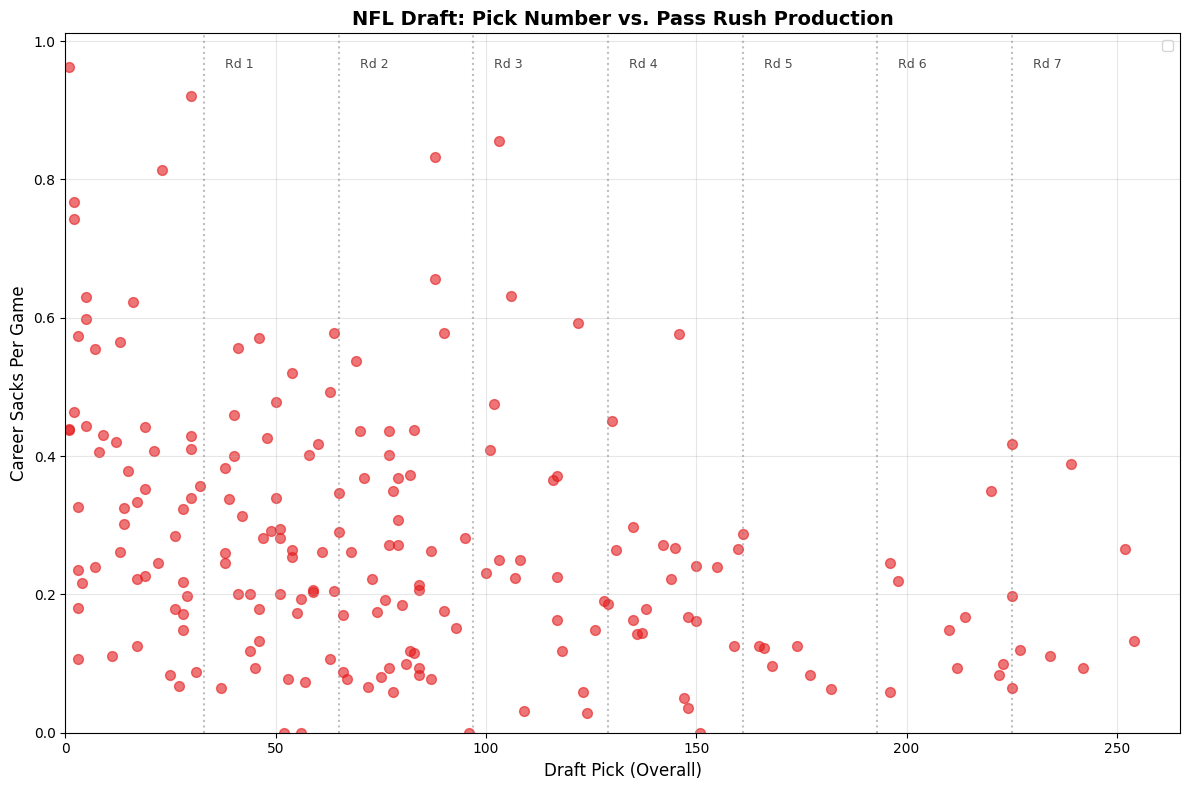


PRODUCTION BY DRAFT ROUND
----------------------------------------
             Count  Median SPG  Mean SPG  Pct > 0.3 SPG
round_group                                            
Round 1         50       0.336     0.375          0.600
Round 2         43       0.261     0.277          0.372
Round 3         45       0.231     0.275          0.356
Round 4         23       0.223     0.248          0.261
Round 5         20       0.164     0.181          0.050
Round 6          7       0.148     0.145          0.000
Round 7         12       0.126     0.194          0.250


In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


DL_summary = pd.read_csv('dl_analysis_data.csv')


edge_rushers = DL_summary[DL_summary['position_group'] == 'Edge'].copy()

# Filter to drafted players only (has draft pick number)
drafted = edge_rushers[edge_rushers['overall_pick'].notna()].copy()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Edge and Interior separately
ax.scatter(
    drafted['overall_pick'], 
    drafted['nfl_sacks_per_game'],
    alpha=0.6,
    s=50,
    c='#E41A1C',
    marker='o'
)

# Add reference lines for draft rounds
round_boundaries = [33, 65, 97, 129, 161, 193, 225]  # Start of rounds 2-7
round_labels = ['Rd 1', 'Rd 2', 'Rd 3', 'Rd 4', 'Rd 5', 'Rd 6', 'Rd 7']
for i, boundary in enumerate(round_boundaries):
    ax.axvline(x=boundary, color='gray', linestyle=':', alpha=0.5)
    ax.text(boundary + 5, ax.get_ylim()[1] * 0.95, round_labels[i], 
            fontsize=9, alpha=0.7)

# Labels and title
ax.set_xlabel('Draft Pick (Overall)', fontsize=12)
ax.set_ylabel('Career Sacks Per Game', fontsize=12)
ax.set_title('NFL Draft: Pick Number vs. Pass Rush Production', fontsize=14, fontweight='bold')


ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 265)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('draft_position_vs_sacks_per_game.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print summary stats by round
print("\n" + "=" * 80)
print("PRODUCTION BY DRAFT ROUND")
print("-" * 40)

drafted['round_group'] = drafted['draft_round'].apply(
    lambda x: f"Round {int(x)}" if pd.notna(x) else "Undrafted"
)

round_summary = drafted.groupby('round_group').agg({
    'nfl_sacks_per_game': ['count', 'median', 'mean', lambda x: (x >= 0.3).sum() / len(x)]
}).round(3)

round_summary.columns = ['Count', 'Median SPG', 'Mean SPG', 'Pct > 0.3 SPG']
print(round_summary)

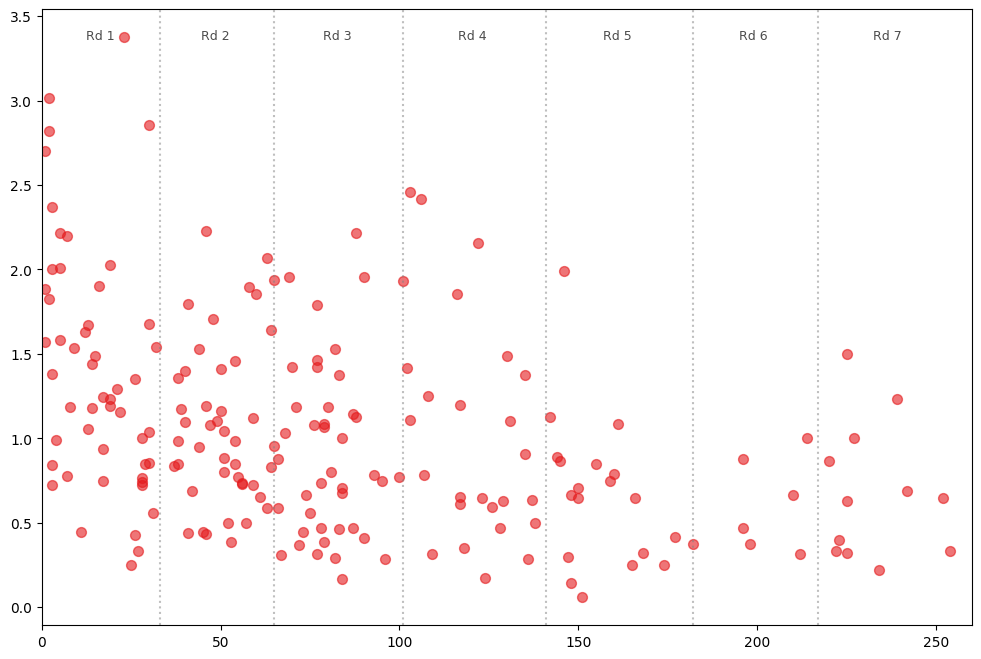

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to drafted players only (has draft pick number)
drafted = edge_rushers[edge_rushers['overall_pick'].notna()].copy()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    drafted['overall_pick'],
    drafted['nfl_pressures_per_game'],
    alpha=0.6,
    s=50,
    c='#E41A1C',
    marker='o'
)

# Add reference lines for draft rounds
round_starts = [1, 33, 65, 101, 141, 182, 217, 257]  # Including start of Round 1 and end boundary

# Add vertical lines at round boundaries, based on 2026
# Numbers vary based on comp pick
for i, boundary in enumerate(round_starts[1:-1]):  # Skip the first (1) and last (225)
    ax.axvline(x=boundary, color='gray', linestyle=':', alpha=0.5)

# Add round labels at midpoints
for i in range(7):
    start = round_starts[i]
    end = round_starts[i+1] - 1
    midpoint = (start + end) / 2
    ax.text(midpoint, ax.get_ylim()[1] * 0.95, f'Rd {i+1}', 
            fontsize=9, ha='center', alpha=0.7)

# Set x-axis limits to remove buffer
ax.set_xlim(0, 260)

plt.show()



75th percentile threshold (Edge): 0.367 sacks/game


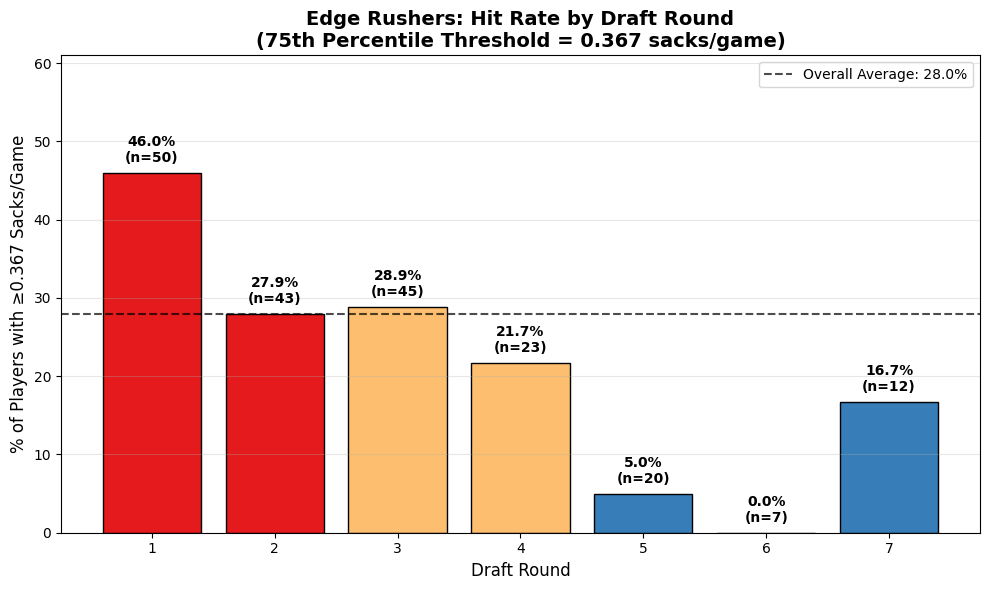


EDGE RUSHERS: HIT RATE BY ROUND
Threshold (75th percentile): 0.367 sacks/game
------------------------------------------------------------
 round  total_players  above_threshold  hit_rate
     1             50               23 46.000000
     2             43               12 27.906977
     3             45               13 28.888889
     4             23                5 21.739130
     5             20                1  5.000000
     6              7                0  0.000000
     7             12                2 16.666667
------------------------------------------------------------
Overall hit rate: 28.0% (56/200 players)


In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get the 75th percentile threshold for edge rushers
threshold_75 = edge_rushers['nfl_sacks_per_game'].quantile(0.75)
print(f"75th percentile threshold (Edge): {threshold_75:.3f} sacks/game")

# Filter to drafted edge rushers only
drafted_edge = edge_rushers[edge_rushers['draft_round'].notna()].copy()

# Calculate hit rate by round
round_stats = []
for round_num in sorted(drafted_edge['draft_round'].unique()):
    round_players = drafted_edge[drafted_edge['draft_round'] == round_num]
    total_players = len(round_players)
    above_threshold = len(round_players[round_players['nfl_sacks_per_game'] >= threshold_75])
    hit_rate = (above_threshold / total_players) * 100
    
    round_stats.append({
        'round': int(round_num),
        'total_players': total_players,
        'above_threshold': above_threshold,
        'hit_rate': hit_rate
    })

round_stats_df = pd.DataFrame(round_stats)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    round_stats_df['round'], 
    round_stats_df['hit_rate'],
    color=['#E41A1C' if r <= 2 else '#FDBF6F' if r <= 4 else '#377EB8' for r in round_stats_df['round']],
    edgecolor='black',
    linewidth=1
)

# Add value labels on top of each bar
for bar, hit_rate, total in zip(bars, round_stats_df['hit_rate'], round_stats_df['total_players']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{hit_rate:.1f}%\n(n={total})',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Add horizontal line for overall average hit rate
overall_hit_rate = (len(drafted_edge[drafted_edge['nfl_sacks_per_game'] >= threshold_75]) / len(drafted_edge)) * 100
ax.axhline(y=overall_hit_rate, color='black', linestyle='--', alpha=0.7, 
           label=f'Overall Average: {overall_hit_rate:.1f}%')

# Labels and title
ax.set_xlabel('Draft Round', fontsize=12)
ax.set_ylabel(f'% of Players with ≥{threshold_75:.3f} Sacks/Game', fontsize=12)
ax.set_title(f'Edge Rushers: Hit Rate by Draft Round\n(75th Percentile Threshold = {threshold_75:.3f} sacks/game)', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(round_stats_df['hit_rate']) + 15)
ax.set_xticks(round_stats_df['round'])
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('edge_hit_rate_by_round.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detailed stats
print("\n" + "=" * 60)
print("EDGE RUSHERS: HIT RATE BY ROUND")
print("=" * 60)
print(f"Threshold (75th percentile): {threshold_75:.3f} sacks/game")
print("-" * 60)
print(round_stats_df.to_string(index=False))
print("-" * 60)
print(f"Overall hit rate: {overall_hit_rate:.1f}% ({len(drafted_edge[drafted_edge['nfl_sacks_per_game'] >= threshold_75])}/{len(drafted_edge)} players)")

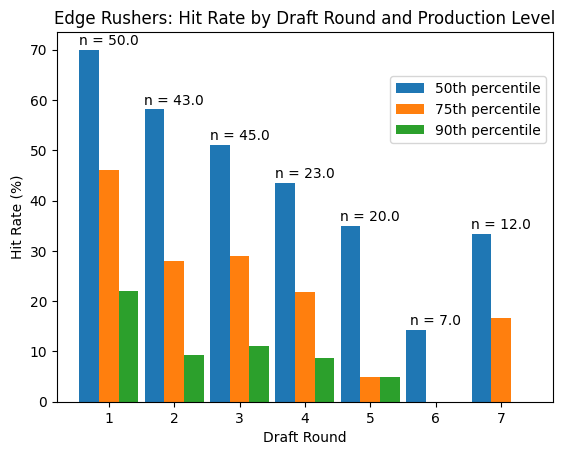

50% Stats
 round  total_players  above_threshold  hit_rate
     1             50               35 70.000000
     2             43               25 58.139535
     3             45               23 51.111111
     4             23               10 43.478261
     5             20                7 35.000000
     6              7                1 14.285714
     7             12                4 33.333333
75% Stats
 round  total_players  above_threshold  hit_rate
     1             50               23 46.000000
     2             43               12 27.906977
     3             45               13 28.888889
     4             23                5 21.739130
     5             20                1  5.000000
     6              7                0  0.000000
     7             12                2 16.666667
90% Stats
 round  total_players  above_threshold  hit_rate
     1             50               11 22.000000
     2             43                4  9.302326
     3             45                5 

<Figure size 640x480 with 0 Axes>

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

drafted_edge = edge_rushers[edge_rushers['draft_round'].notna()].copy()

threshold_50 = edge_rushers['nfl_sacks_per_game'].quantile(.50)
threshold_75 = edge_rushers['nfl_sacks_per_game'].quantile(.75)
threshold_90 = edge_rushers['nfl_sacks_per_game'].quantile(.90)

# players above the 75% threshold
above = drafted_edge['nfl_sacks_per_game'] >= threshold_75

hit_50 = []
hit_75 = []
hit_90 = []

for round_num in range(1,8):
    current = drafted_edge['draft_round'] == round_num
    round_players = drafted_edge[current]
    round_total = len(drafted_edge[current])

    # calculate percetage hitting each threshold per round
    hit_threshold_50_rate = (round_players['nfl_sacks_per_game'] >= threshold_50).mean() * 100
    hit_threshold_50_count = len(round_players[round_players['nfl_sacks_per_game'] >= threshold_50])
    hit_threshold_75_rate = (round_players['nfl_sacks_per_game'] >= threshold_75).mean() * 100
    hit_threshold_75_count = len(round_players[round_players['nfl_sacks_per_game'] >= threshold_75])
    hit_threshold_90_rate = (round_players['nfl_sacks_per_game'] >= threshold_90).mean() * 100
    hit_threshold_90_count = len(round_players[round_players['nfl_sacks_per_game'] >= threshold_90])



    hit_50.append({
        'round': int(round_num),
        'total_players': round_total,
        'above_threshold': hit_threshold_50_count,
        'hit_rate': hit_threshold_50_rate
    })
    hit_75.append({
        'round': int(round_num),
        'total_players': round_total,
        'above_threshold': hit_threshold_75_count,
        'hit_rate': hit_threshold_75_rate
    })
    hit_90.append({
        'round': int(round_num),
        'total_players': round_total,
        'above_threshold': hit_threshold_90_count,
        'hit_rate': hit_threshold_90_rate
    })
    # total players in a round

h50_df = pd.DataFrame(hit_50)
h75_df = pd.DataFrame(hit_75)
h90_df = pd.DataFrame(hit_90)

rounds = list(h50_df['round'])
x = np.arange(len(rounds))
width = 0.3

plt.bar(x - width, h50_df['hit_rate'], width, label='50th percentile')
plt.bar(x, h75_df['hit_rate'], width, label='75th percentile')
plt.bar(x + width, h90_df['hit_rate'], width, label='90th percentile')


# Change x-axis labels to round numbers
plt.xticks(x, rounds)
plt.xlabel('Draft Round')
plt.ylabel('Hit Rate (%)')
plt.title('Edge Rushers: Hit Rate by Draft Round and Production Level')
plt.legend(bbox_to_anchor=(1, .9), loc='upper right')


# adding total player count per round
for round_num in range(1,8):
    x_position = round_num - 1
    y_position = h50_df.iloc[round_num - 1]['hit_rate'] + 1
    count = h50_df.iloc[round_num - 1]['total_players']
    plt.text(x_position, y_position, f"n = {count}", ha='center')

plt.show()

print("50% Stats")
print(h50_df.to_string(index=False))
print("75% Stats")
print(h75_df.to_string(index=False))
print("90% Stats")
print(h90_df.to_string(index=False))


plt.savefig('edge_hit_rate_by_round.png', dpi=150, bbox_inches='tight')


***
### Edge NFL Sack Production Takeaways

**1. There are two big cliffs for sack production: Round 1 and Round 4.** After round one, the numbers are staggeringly different. At the 50th percentile, it drops from a 70% hit rate to 58% in the next highest round. At the 75th percentile, it drops from 46% to nearly 29%. And for 90 percentile, it drops from 22% to around 11%. Needless to say, 1st round evaluations on edge rushers have a much higher success rate than any other round, based on sack per game production. The round 4 cliff, while not as prominent, is still noticible. The respective dropsoffs from worse round 1-4 hit percentage to best round 5-7 hit percentage is 8%, 5%, and 3%, with rounds 6 and 7 producing no 90th percentile sack production, and a dismal 3 total players in rounds 5 through 7 with a 75th or higher percentile in sack production.

**2. Rounds 2 and 3 produce very similar results.** In the years we have data on (2018 to 2025 NFL Stats, players drafted from 2013 to now), there have been 43 players listed as edge in the second round and 45 in the third. While that number is already remarkably similar, the results that were found on sack per game production were even more shocking. While round two boasts a 7% lead in terms of hit rate in the 50th percentile (meaning there are less busts in round two than there are in round three), the numbers in the 75th percentile and 90th percentile actually slightly favor round three, leading each category by 1% and 2%. This means edge rushers are slightly more likely to be higher end sack producers in round three than they are in round too, but they also have a bigger chance of busting. This could possibly be attributed to bigger swings in round three. Maybe edge rushers with better measurables but less college production are given a chance in round three while more proven staticians are given the nod in round two. 

**3. Round 6 is a dud.** While it is hard to fully take a lot away from round six, because our data shows only seven drafted players in this time frame, there has been very little to be impressed by in this round. Out of the seven players, only one has been above the 50 percentile sack production, while none have been above 75 or 90 percentile. Our data doesn't account for all players, but it accounts for players who have put up enough meaningful stats in the NFL. This means that the percentages of round six duds would be even worse if it had accounted for every single player drafted in this round. 

**4. Round 7 and Round 5 have found similar production.** Rounds five through seven also produce small sample sizes (20 and 12 players), again because of the number of players throughout these rounds who don't produce anything. Given that there are nearly double the players in round seven in our sample size as round six, and nearly triple the players in round 5 in our sample size as opposed to round six, we can take something away from there: there are simply more players that see the field in rounds five and seven than there are in round six. As far as 50th percentile and above production, that's where our data comes in. While there is a limited number of both fifth and seventh rounders that hit the 50th percentile mark, the numbers are very close, at 35% in round five and 33.3% in round seven. The 75th percentile numbers, while still small, favor round seven, with 16.7% of players hitting that mark and only 5% hitting it in round 5. That player in round 5? Matthew Judon, who also hits the 90th percentile mark, the only player in either of the two rounds to do so.  

**The bottom line:** 

***